___

In [1]:
# Imports
from pyspark.sql import SparkSession
import pyspark.sql.functions as f

# (I can't get no) satisfaction
Wir arbeiten weiterhin mit dem Datensatz über die Zufriedenheit von Angestellten einer fiktiven Firma. In dieser Kurseinheit betrachten wir die parallele Verarbeitung mit Spark. 

*Anmerkung: Der verwendete Datensatz ist natürlich eher klein, so dass normalerweise keine Parallelisierung benötigt wird. In der Kurseinheit dient er aber dazu, die grundlegenden Konzepte von Spark zu vermitteln.*

Wichtige Methoden finden Sie im Foliensatz, es empfiehlt sich jedoch auch, die <a href="https://spark.apache.org/docs/latest/api/python/reference/index.html">pyspark-Doku</a> für die Bearbeitung zu nutzen.

In dieser Kurseinheit werden u.a. Lambda-Funktionen verwendet. Wenn Sie damit noch nicht vetraut sind, hilft ein Blick in die <a href="https://www.w3schools.com/python/python_lambda.asp">Python-Lambdas-Doku</a>.

<div class="alert alert-block alert-warning">
    
Zudem zu Anfang noch ein paar Hinweise zur Arbeit mit Spark:
    
- Shuffling ist eine teure Operation, die Folgendes beinhaltet: *Festplatten-I/O*, *Serialisierung und Deserialisierung von Daten* und *Netzwerk-I/O*. Shuffle-Operationen können nicht vollständig vermieden werden, es sollte aber versucht werden, wenn möglich, die Anzahl der Shuffle-Operationen zu reduzieren, indem ungenutzte Operationen entfernt werden.

- Bei der Arbeit mit Dataframes sollten UDFs auf jeden Fall vermieden werden. Verwenden Sie sie nur, wenn die vorhandenen integrierten Spark-Funktionen nicht zur Verfügung stehen. UDFs sind eine Blackbox für Spark und können daher nicht optimiert werden. Somit gehen alle Optimierungen, die Spark für Dataframe/Dataset durchführt, verloren. Wenn möglich, sollten die integrierten SQL-Funktionen von Spark verwenden werden, da diese Funktionen Optimierungsmöglichkeiten bieten.

- Bei der Arbeit mit Spark sollten alle Daten als Spark-Struktur dargestellt werden. So sollten bspw. for-Schleifen vermieden werden. Durch die Lazy Evaluation werden Transformationen in einer for-Schleife nicht sequentiell abgearbeitet. Stattdessen werden all diese Aufrufe aggregiert und dann gleichzeitig ausgeführt, wenn eine Action aufgerufen wird. Dies führt zu zahlreichen parallelen Aufgaben, die gleichzeitig ausgeführt werden sollen. Wenn stattdessen lediglich Spark-Strukturen verwendet werden, kann Spark die Aufrufe intern optimieren und es ist kompatibel mit der Ressourcenverwaltung und anderen Verhaltensweisen des Spark-Frameworks. Dies kann, gerase aus objektorientierter Sicht, zu ungewohnten Strukturen führen, die sich redundant anfühlen. Hier ist also ein Umdenken erforderlich.
</div>

Den Eintrittspunkt in die Funktionalität von Spark stellt der SparkContext dar. Dieser repräsentiert auch die Verbindung zu den Exekutoren. Bei der Erstellung wird außerdem eine Sammlung von Konfigurationsparametern mitgegeben. Wir beschränken uns zunächst auf die Angabe des Masters und einem App-Namen:
- **master:** Wir verwenden YARN als Ressourcen-Manager und starten die Anwendung im Client-Modus.
- **appName:** Hier vergeben wir einen Namen für unsere Applikation.

Da wir später auch mit SparkSQL arbeiten wollen, erstellen wir zudem direkt eine SparkSession. Diese stellt den Eingangspunkt für die SparkSQL-Funktionalität zur Verfügung und beinhaltet auch den SparkContext.

In [2]:
# SparkSession erstellen
spark = SparkSession.builder \
    .master("yarn") \
    .appName("KE5") \
    .getOrCreate()

# SparkContext
sc = spark.sparkContext

## RDDs
Zunächst betrachten wir die Arbeit mit RDDs. Wie Sie in den Vorlesungsvideos gelernt haben, bilden diese die Grundlage der parallelen Verarbeitung. In der Praxis wird meist nicht direkt mit RDDs, sondern mit einer High-level-Bibliothek wie SparkSQL gearbeitet. Es ist jedoch wichtig, die Konzepte von RDDs zu verstehen, da diese die Basis von Spark darstellen. 

### Eigenschaften von RDDs
Betrachten wir zunächst die wichtigsten Eigenschaften von RDDs:
- In-Memory-Verarbeitung
- Lazy
- Partitioniert
- Unveränderlich
- Lineage

#### In-Memory-Verarbeitung
Beschreiben Sie die Vorteile der In-Memory-Verarbeitung.

#### Lazy
Beschreiben Sie, was es für die Programmierung bedeutet, dass die Verarbeitung lazy ausgeführt wird. Programmieren Sie ein **Spark**-Code-Beispiel Ihrer Wahl, in dem Sie die Auswirkungen der lazy Ausführung demonstrieren. Erläutern Sie Ihr Beispiel in der darunterstehenden Zelle. Nennen Sie zudem die wichtigsten Unterschiede zwischen Transformations und Actions.

***Hinweis zur Korrektur:*** *Hier sind diverse Code-Beispiele möglich. Alle Beispiele, bei denen deutlich zu erkennen ist, dass eine Ausführung des Codes erst später erfolgt, können als korrekt bewertet werden, insofern es sich um Spark-Code handelt.*

In [3]:
# Ihr Beispiel für eine lazy Ausführung
rdd = sc.parallelize([1, 2, 3, 4])
error = rdd.map(lambda x: x/0) # -> Division durch 0 ist nicht möglich, hier tritt aber noch kein Fehler auf

In [4]:
error.collect() # -> hier wird erst die eigentliche Verarbeitung gestartet, deshalb taucht auch hier erst der Fehler auf

24/08/28 05:58:26 ERROR TaskSetManager: Task 1 in stage 0.0 failed 4 times; aborting job



[Stage 0:>                                                          (0 + 3) / 5]



Py4JJavaError: An error occurred while calling z:org.apache.spark.api.python.PythonRDD.collectAndServe.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 0.0 failed 4 times, most recent failure: Lost task 1.3 in stage 0.0 (TID 9) (hadoop-worker-1 executor 2): org.apache.spark.api.python.PythonException: Traceback (most recent call last):
  File "/tmp/hadoop-hadoop/nm-local-dir/usercache/pyspark-client/appcache/application_1724824450484_0001/container_1724824450484_0001_01_000003/pyspark.zip/pyspark/worker.py", line 619, in main
    process()
  File "/tmp/hadoop-hadoop/nm-local-dir/usercache/pyspark-client/appcache/application_1724824450484_0001/container_1724824450484_0001_01_000003/pyspark.zip/pyspark/worker.py", line 611, in process
    serializer.dump_stream(out_iter, outfile)
  File "/tmp/hadoop-hadoop/nm-local-dir/usercache/pyspark-client/appcache/application_1724824450484_0001/container_1724824450484_0001_01_000003/pyspark.zip/pyspark/serializer

#### Partitioniert
Erstellen Sie aus der vorgegebenen Liste (`data`) ein RDD namens `rdd_part` mit drei Partitionen. Kontrollieren Sie nach der Erstellung, dass die korrekte Anzahl Partitionen erzeugt wurde.

In [5]:
data = [1 for i in range (10)] + [0 for i in range (5)]

In [ ]:
# Ihre Lösung

In [6]:
# RDD erstellen
rdd_part = sc.parallelize(data, 3)

In [7]:
# Anzahl Partitionen anzeigen
rdd_part.getNumPartitions()

3

Im Folgenden schauen wir uns die Verteilung der Daten auf die unterschiedlichen Partitionen an.

> **Achtung:** Die Anwendung von `collect()` in Kombination mit `glom()` ist nur für kleine Datensätze geeignet!

In [8]:
rdd_part.glom().collect()

[[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [0, 0, 0, 0, 0]]

Wie wir sehen können, bestehen zwei Partitionen aus 1en und eine aus 0en. Filtern Sie das RDD nun so, dass nur die Werte größer 0 übrig bleiben. Erstellen Sie hierfür ein neues RDD namens `rdd_filtered`.

In [9]:
# Ihre Lösung
rdd_filtered = rdd_part.filter(lambda x: x > 0)

Wenn wir uns nun die Verteilung der Daten auf die Partitionen ansehen, sehen wir, dass wir eine leere Partition erzeugt haben:

In [10]:
rdd_filtered.glom().collect()

[[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], []]

Beschreiben Sie die Nachteile von leeren Partitionen. Wie kann dieses Problem gelöst werden (Stichwort *Shuffling*) und warum sollte Shuffling normalerweise vermieden werden?

#### Unveränderlich und Lineage
Warum sind RDDs unveränderlich und warum kennt jedes RDD seine Abstammung (Lineage)?

### Daten laden
Laden Sie den Datensatz `employees_satisfaction_transformed.csv` in ein RDD. Denken Sie daran, dass die Daten standardmäßig aus dem HDFS geladen werden. Aus diesem Grund müssen die Daten zunächst ins HDFS geladen werden. Verwenden Sie hierzu das Notebook `hdfs-upload.ipynb`, das wir Ihnen in Moodle zur Verfügung gestellt haben.

Laden Sie anschließend die Daten in ein RDD.

In [11]:
# Ihre Lösung
rdd = sc.textFile("employees_satisfaction_transformed.csv")

### Erste Datenexploration

Lassen Sie sich dann die ersten zehn Zeilen des RDDs anzeigen.

In [12]:
# Ihre Lösung
rdd.take(10)


[Stage 3:>                                                          (0 + 1) / 1]



[',age,department,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,satisfied',
 '0,28,HR,Postgraduate,Referral,5,2.0,1,0,78075.0,Male,2019-02-01,1',
 '1,50,Technology,Postgraduate,Recruitment Agency,3,5.0,2,1,38177.1,Male,2017-01-17,0',
 '2,43,Technology,Undergraduate,Referral,4,1.0,2,0,59143.5,Female,2012-08-27,1',
 '3,44,Sales,Postgraduate,On-Campus,2,3.0,0,0,26824.5,Female,2017-07-25,1',
 '4,33,HR,Undergraduate,Recruitment Agency,2,1.0,5,0,26824.5,Male,2019-05-17,1',
 '5,40,Purchasing,Undergraduate,Walk-in,3,3.0,7,1,38177.1,Male,2004-04-22,1',
 '6,26,Purchasing,Undergraduate,Referral,5,5.0,2,0,78075.0,Male,2019-12-10,1',
 '7,25,Technology,Undergraduate,Recruitment Agency,1,1.0,4,0,21668.4,Female,2017-03-18,0',
 '8,35,HR,Postgraduate,Referral,3,4.0,0,0,38177.1,Female,2015-04-02,1']

Die erste Zeile entspricht dem Header. Entfernen Sie diese aus dem Datensatz.

***Hinweis zur Korrektur:*** *Alle Lösungen, bei denen korrekt die erste Zeile entfernt wird, sind in Ordnung. Diese muss nicht zwangsläufig mit `first()` identifiziert werden.*

In [13]:
# Ihre Lösung
header = rdd.first()
employees = rdd.filter(lambda line: line!= header)


[Stage 4:>                                                          (0 + 1) / 1]



Zählen Sie nun die Anzahl der Angestellten.

In [14]:
# Ihre Lösung
employees.count()


[Stage 5:=============================>                             (1 + 1) / 2]



498

### Datenverarbeitung

Zählen Sie nun die Angestellten pro Department.

*Sollten Sie keinen Lösungsansatz haben, finden Sie unter dem Button "Show Solution" die Beschreibung der notwendigen Verarbeitungs-Schritte.*

1. Aktuell ist jede Zeile des RDD ein String, in dem die einzelnen Felder durch Komma getrennt sind. Dieser String muss zunächst gesplittet werden.
2. Im nächsten Schritt müssen Key-Value-Paare gebildet werden. Der Key ist das Department und der Wert ist 1.
3. Dann müssen pro Key alle Werte addiert werden.

*Wenn Sie Probleme mit der konkreten Umsetzung der Aufgabe haben, finden Sie unter dem Button "Show Solution" Hinweise zur Programmierung.*

- Das Splitten der einzelnen Funktionen erfolgt mit `split(",")`.
- Anschließend liegen die Daten in einer Liste vor. Das dritte Element (`line[2]`) entspricht dem Department.
- Mithilfe der Funktion `reducyByKey()` können die Werte pro Key addiert werden. 

In [ ]:
# Ihre Lösung

In [15]:
# 1. Zeilen splitten
lines = employees.map(lambda line: line.split(","))

In [16]:
# 2. Key-Value-Paare bilden
key_values = lines.map(lambda line: (line[2], 1))

In [17]:
# 3. Werte pro Key addieren
result = key_values.reduceByKey(lambda x, y: x+y)
# Alternativ kann auch der Operator "add" verwendet werden (from operator import add)

In [18]:
# Ergebnis anzeigen
result.collect()

[('Sales', 87),
 ('Purchasing', 114),
 ('HR', 106),
 ('Technology', 98),
 ('Marketing', 93)]

Die Arbeit mit RDDs ist offensichtlich recht mühsam, weshalb in der Praxis häufig eine High-level API wie SparkSQL verwendet wird. Diese schauen wir uns im Folgenden an.

***Hinweis zur Korrektur:*** *Wichtig für die Bewertung ist die korrekte Ausgabe der Anzahl Angestellter pro Department. Unterschiedliche Code-Lösungen sind möglich.*

## DataFrames
Im Folgenden arbeiten wir mit der High-level API SparkSQL.

*Vorsicht: DataFrames sind die zentrale Abstraktion der SparkSQL-Bibiliothek. Die Bibliothek bietet zwei praktisch gleichwertige APIs, um mit DataFrames zu arbeiten: Die **DataFrame API** und die **SQL API**. Wir arbeiten zunächst mit der DataFrame API.*

### Daten laden
Laden Sie die Daten aus der Datei `employees_satisfaction_transformed.csv` in ein DataFrame. Die Spaltenbezeichnungen sollen dabei im Header stehen und nicht Teil der Daten sein, nutzen Sie außerdem die automatische Schemaerkennung von Spark.

In [19]:
# Ihre Lösung
df = spark.read.csv(path="employees_satisfaction_transformed.csv", header=True, inferSchema=True)

Lassen Sie sich das Schema ausgeben.

In [20]:
# Ihre Lösung
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- department: string (nullable = true)
 |-- education: string (nullable = true)
 |-- recruitment_type: string (nullable = true)
 |-- job_level: integer (nullable = true)
 |-- rating: string (nullable = true)
 |-- awards: integer (nullable = true)
 |-- certifications: integer (nullable = true)
 |-- salary: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- entry_date: string (nullable = true)
 |-- satisfied: integer (nullable = true)



Lassen Sie sich die Daten anzeigen.

In [21]:
# Ihre Lösung
df.show()

+---+---+----------+-------------+------------------+---------+------+------+--------------+-------+------+----------+---------+
|_c0|age|department|    education|  recruitment_type|job_level|rating|awards|certifications| salary|gender|entry_date|satisfied|
+---+---+----------+-------------+------------------+---------+------+------+--------------+-------+------+----------+---------+
|  0| 28|        HR| Postgraduate|          Referral|        5|   2.0|     1|             0|78075.0|  Male|2019-02-01|        1|
|  1| 50|Technology| Postgraduate|Recruitment Agency|        3|   5.0|     2|             1|38177.1|  Male|2017-01-17|        0|
|  2| 43|Technology|Undergraduate|          Referral|        4|   1.0|     2|             0|59143.5|Female|2012-08-27|        1|
|  3| 44|     Sales| Postgraduate|         On-Campus|        2|   3.0|     0|             0|26824.5|Female|2017-07-25|        1|
|  4| 33|        HR|Undergraduate|Recruitment Agency|        2|   1.0|     5|             0|26824

Geben Sie die Anzahl Angestellter aus.

In [22]:
# Ihre Lösung
df.count()

498

DataFrames basieren auf RDDs. Deshalb kann auch jedes DataFrame in ein RDD umgewandelt werden.

Erstellen Sie aus dem DataFrame der Angestellten ein RDD und lassen Sie sich die ersten fünf Zeilen anzeigen.

In [23]:
# Ihre Lösung
df.rdd.take(5)

[Row(_c0=0, age=28, department='HR', education='Postgraduate', recruitment_type='Referral', job_level=5, rating='2.0', awards=1, certifications=0, salary=78075.0, gender='Male', entry_date='2019-02-01', satisfied=1),
 Row(_c0=1, age=50, department='Technology', education='Postgraduate', recruitment_type='Recruitment Agency', job_level=3, rating='5.0', awards=2, certifications=1, salary=38177.1, gender='Male', entry_date='2017-01-17', satisfied=0),
 Row(_c0=2, age=43, department='Technology', education='Undergraduate', recruitment_type='Referral', job_level=4, rating='1.0', awards=2, certifications=0, salary=59143.5, gender='Female', entry_date='2012-08-27', satisfied=1),
 Row(_c0=3, age=44, department='Sales', education='Postgraduate', recruitment_type='On-Campus', job_level=2, rating='3.0', awards=0, certifications=0, salary=26824.5, gender='Female', entry_date='2017-07-25', satisfied=1),
 Row(_c0=4, age=33, department='HR', education='Undergraduate', recruitment_type='Recruitment Age

Das RDD besteht aus einzelnen Rows. Mittels Index kann auf die einzelnen Rows zugegriffen werden. Der Zugriff auf die Spalten erfolgt entweder auch durch die Angabe des Index oder durch den Spaltennamen.

Lassen Sie sich das Gehalt der ersten Row ausgeben.

In [24]:
# Ihre Lösung
df.rdd.collect()[0]["salary"]

78075.0

In [25]:
# Alternative mit Spalten-Index
df.rdd.collect()[0][9]

78075.0

### Verarbeitung
*Hinweis: Für die Bearbeitung der folgenden Aufaben ist es hilfreich, sich die `pyspark.sql.functions` anzusehen. Diese sind bereits importiert und können mit `f.<function_name>` verwendet werden.*

Fügen Sie eine neue Spalte `service_days` hinzu, in der angegeben wird, seit wie vielen Tagen ein\*e Angestellte\*r im Unternehmen ist. Verwenden Sie als Stichtag den 01.01.2021 (`comparison`)

In [26]:
comparison = "2021-01-01"

In [27]:
# Ihre Lösung
df = df.withColumn("service_days", f.datediff(f.lit(comparison), f.col("entry_date")))

Lassen Sie sich anschließend das Eintrittsdatum und die Tage im Unternehmen von allen Angestellten anzeigen, die länger als 6000 Tage im Unternehmen sind.

In [28]:
# Ihre Lösung
df.select("entry_date", "service_days").where(f.col("service_days")>6000).show()

+----------+------------+
|entry_date|service_days|
+----------+------------+
|2004-04-22|        6098|
|2004-03-19|        6132|
|2004-01-16|        6195|
|2004-07-13|        6016|
|2004-02-24|        6156|
|2004-07-15|        6014|
|2004-06-20|        6039|
|2004-01-20|        6191|
|2004-06-01|        6058|
|2004-04-19|        6101|
|2004-04-13|        6107|
|2004-07-05|        6024|
|2004-06-08|        6051|
|2004-01-20|        6191|
|2004-01-22|        6189|
|2004-01-05|        6206|
|2004-04-17|        6103|
|2004-07-05|        6024|
+----------+------------+



### Analyse

Lassen Sie sich die Departments des Datensatzes anzeigen (jedes nur einmal).

In [29]:
# Ihre Lösung
df.select("department").distinct().show()

+----------+
|department|
+----------+
|     Sales|
|        HR|
|Purchasing|
| Marketing|
|Technology|
+----------+



Ermitteln Sie (wie eben bei der Arbeit mit RDDs) die Anzahl Angestellte pro Department.

In [30]:
# Ihre Lösung
df.groupby("department").count().show()

+----------+-----+
|department|count|
+----------+-----+
|     Sales|   87|
|        HR|  106|
|Purchasing|  114|
| Marketing|   93|
|Technology|   98|
+----------+-----+



Geben Sie durchschnittliche Zufriedenheit aller Personen aus, die in der Abteilung *HR* arbeiten, sowie das Alter der ältesten Person der Abteilung.

In [31]:
# Ihre Lösung
df \
  .where(f.col("department")=="HR") \
  .agg({"satisfied": "mean", "age": "max"}) \
  .show()

+------------------+--------+
|    avg(satisfied)|max(age)|
+------------------+--------+
|0.6886792452830188|      54|
+------------------+--------+



Wie erstellen nun ein weiteres DataFrame. Erstellen Sie aus den Daten in `dept_data` das DataFrame `departments` mit den angegebenen Spaltennamen. Geben Sie das erzeugte DataFrame aus.

In [32]:
dept_data = [("Sales", "New York", 10001), 
            ("HR", "Los Angeles", 90001),
            ("Purchasing", "San Francisco", 94104),
            ("Marketing", "Philadelphia", 19110),
            ("Technology", "Los Angeles", 90099)]

column_names = ["name", "location", "zip_code"]

In [33]:
# Ihre Lösung
departments = spark.createDataFrame(dept_data, column_names)
departments.show()

+----------+-------------+--------+
|      name|     location|zip_code|
+----------+-------------+--------+
|     Sales|     New York|   10001|
|        HR|  Los Angeles|   90001|
|Purchasing|San Francisco|   94104|
| Marketing| Philadelphia|   19110|
|Technology|  Los Angeles|   90099|
+----------+-------------+--------+



Wie viele Angestellte arbeiten in Los Angeles?

In [34]:
# Ihre Lösung
df \
.join(departments, df.department == departments.name) \
.where(departments.location == "Los Angeles") \
.count()

204

Lassen Sie sich die ersten 10 Gehälter der Angestellten ausgeben, die an der Ostküste arbeiten (in diesem Fall `zip_code < 90000`).

In [35]:
# Ihre Lösung
df \
.join(departments, df.department == departments.name) \
.where(departments.zip_code < 90000) \
.select("salary") \
.show(10)

+-------+
| salary|
+-------+
|38177.1|
|38177.1|
|59143.5|
|21668.4|
|59143.5|
|21668.4|
|78075.0|
|26824.5|
|38177.1|
|78075.0|
+-------+
only showing top 10 rows



### Caching
Durch die In-Memory-Verarbeitung werden DataFrames in der Regel nicht zwischengespeichert. Mit jeder Action werden alle Verarbeitungsschritte neu ausgeführt. Manchmal kann es aber sinnvoll sein, ein DataFrame zwischenzuspeichern (zu *cachen*). Beim Aufruf der ersten Action wird das DataFrame dann im Speicher gehalten.

(*Hinweis*: Gleiches gilt natürlich auch für RDDs, da DataFrames ja auf RDDs basieren)

Betrachten Sie den folgenden Code: An welcher Stelle könnte es sinnvoll sein, ein Caching durchzuführen und warum? Fügen Sie den Code für das Caching ein. Schreiben Sie in die untere Zelle Ihre Begründung und beschreiben Sie, welche DataFrames auf die gecachte Version zugreifen.

```python
df1 = spark.read.csv(path = "my_data.csv", header = True)
df2 = df1.filter(df1.salary.between(40000, 50000))
df3 = df2.select("name", "salary", "department", "satisfied")
df3.cache() # <- hier eingefügt
df4 = df3.groupby("department").agg({"satisfied": "mean"})
df4.show()
df5 = df3.groupby("department").agg({"salary": "mean"})
df5.show()
df6 = df3.select("name").where(df3["satisfied"] == 1)
df6.show()
```

## SQL
Im Folgenden verwenden wir SQL zur Datenabfrage. Dafür erstellen wir zunächst eine temporale View, auf der dann die SQL-Abfragen erfolgen.

In [36]:
spark.sql("\
CREATE TEMP VIEW employees \
USING CSV \
OPTIONS (path = 'employees_satisfaction_transformed.csv', header = 'True', inferSchema = 'True')")

DataFrame[]

Ermitteln Sie nun wieder die Anzahl der Angestellten pro Department, aber verwenden Sie dieses Mal SQL.

In [37]:
# Ihre Lösung
spark.sql("SELECT department, COUNT(department) FROM employees GROUP BY department").show()

+----------+-----------------+
|department|count(department)|
+----------+-----------------+
|     Sales|               87|
|        HR|              106|
|Purchasing|              114|
| Marketing|               93|
|Technology|               98|
+----------+-----------------+



## Ressourcen-Vebrauch

Sie arbeiten in diesen Übungsaufgaben mit ihrem eigenen Cluster. In der Praxis ist dies natürlich selten der Fall, hier werden meist viele Jobs gleichzeitig gestartet und konkurrieren um Ressourcen.

***Hinweis zur Korrektur*** *Da manche Studierenden die Anforderungen an die Hardware nicht erfüllen, kann es sein, dass sie zu anderen Werten kommen. Wir haben allerdings kommuniziert, dass diese Aufgabe in dem Fall nicht bearbeitet werden kann (oder nur theoretisch), von daher kann sich an den untenstehenden Musterlösungen für die Korrektur gehalten werden.*

<div class="alert alert-block alert-warning">
    
**Hinweis** In dieser Aufgabe müssen Sie teilweise mit einem Terminal innerhalb des Containers arbeiten. Geben Sie dazu entweder den Befehl `docker exec -it dbis-pyspark-client-node bash` auf Ihrem Host-Terminal ein oder erstellen Sie dieses über die Startseite des Jupyter Notebooks mittels *New* -> *Terminal*.
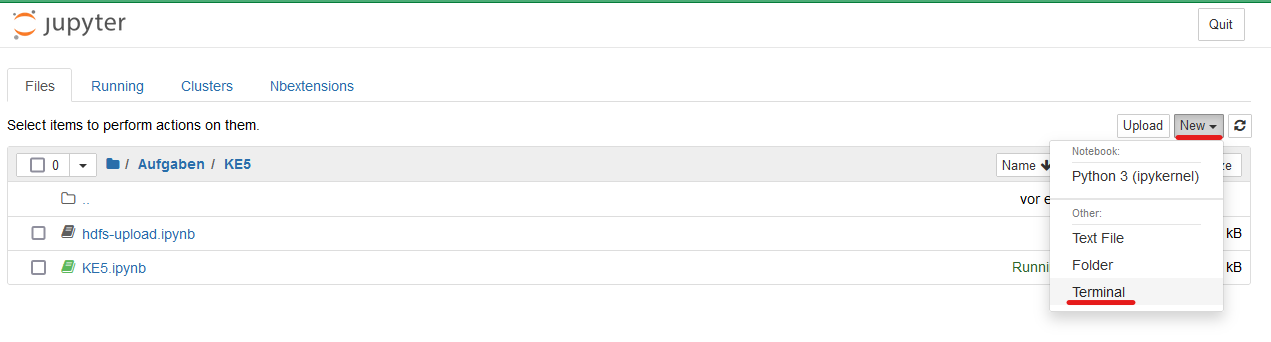
    
</div>

> 

Öffnen Sie die __[WebUI von YARN](http://127.0.0.1:8088)__ und sehen sich die aktuellen Applikationen an. Sie sollten dort das aktuelle Jupyter Notebook finden. Solange die SparkSession (der SparkContext) erstellt ist, wird das Notebook dort als *RUNNING* aufgelistet. 

Wie viele Kerne und wie viel Speicher verbraucht die Spark-Applikation? Wie können Sie diese Summe berechnen?

*Hinweis: Werfen Sie einen Blick in die Datei `spark-defaults.conf` im `SPARK_CONF_DIR`.*

*Sollten Sie nicht wissen, wie Sie diese Datei finden können, finden Sie unter dem "Show Solution"-Button hilfreiche Kommandos.*

- Zugriff auf den Inhalt einer Umgebungs-Variablen mittels `$`, z.B. `$SPARK_CONF_DIR`
- Anzeigen von Dateiinhalten: `cat`

In [38]:
%%bash
# Inhalt von spark-defaults.conf anzeigen lassen
cat $SPARK_CONF_DIR/spark-defaults.conf 

spark.yarn.am.cores 1
spark.executor.memoryOverhead 384M
spark.yarn.am.memory 896M
spark.yarn.am.memoryOverhead 384M
spark.dynamicAllocation.enabled false
spark.executor.cores 1
spark.driver.cores 1
spark.driver.memory 1664M
spark.executor.memory 896M
spark.executor.instances 5


Stoppen Sie den SparkContext, um alle Ressourcen, die dieses Notebook benötigt, freizugeben.

In [39]:
# Ihre Lösung
sc.stop()

Öffnen Sie ein Terminal und starten Sie eine pyspark-Shell mit YARN als Ressourcen-Manager im client-mode mit 2 Exekutoren mit jeweils 1GB Memory und 2 Cores. Wie viele Cores und wie viel Speicher benötigt die Applikation und wie setzen sich diese Zahlen zusammen? Kontrollen Sie in der WebUI von YARN, ob Ihre Berechnungen korrekt sind.

***Hinweis zur Korrektur:*** *Der Aufruf der pyspark-Shell erfolgt im Terminal und muss nicht im Notebook dokumentiert werden. Wichtig bei diesen Aufgaben ist die korrekte Angabe des Ressourcen-Verbrauchs und eine schlüssige Begründung.*

Starten Sie anschließend in einem zweiten Terminal eine weitere pyspark-Shell (ohne die erste Shell zu beenden) mit YARN als Ressourcen-Manager im client-mode mit der gleichen Konfiguration (2 Exekutoren mit jeweils 1GB Memory und 2 Cores). Erstellen Sie dort ein RDD mit den Werten 1, 2, 3, 4 und lassen sich dieses mittels `collect()` ausgeben.

Was passiert und warum? Wie können Sie das Problem beheben?

Schließen Sie beide Shells und starten anschließend eine neue pyspark-Shell mit folgenden Eigenschaften:
- YARN als Ressourcen-Manager im client-mode
- 2 Exekutoren mit jeweils
    - 2GB Memory
    - 3 Cores
    
Wie viele Ressourcen vebraucht diese Applikation und wie setzen sich diese zusammen?

Starten Sie anschließend in einem zweiten Terminal noch eine pyspark-Shell (ohne die erste Shell zu beenden) mit folgendem Befehl:

`pyspark --master yarn --conf spark.yarn.am.cores=3`

Was passiert und warum? Überprüfen Sie auch den Status der Applikation in der WebUI von YARN.